# Prova de Conceito — Sistema de Recomendação de Receitas

Este notebook está corrigido para rodar no PyCharm ou Jupyter.

Atenção: rode as células em ordem.

## 1. Importar bibliotecas

In [2]:
from pathlib import Path
import ast

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error, mean_absolute_error

## 2. Definir pasta do projeto e caminhos dos arquivos

Esta célula cria as variáveis `arquivo_receitas`, `arquivo_interacoes`, `arquivo_treino`, `arquivo_validacao` e `arquivo_teste`.

Ela também funciona quando o notebook está dentro da pasta `notebooks`.

In [5]:
pasta_atual = Path.cwd()

# Se o notebook estiver sendo executado dentro da pasta notebooks,
# voltamos uma pasta para chegar na raiz do projeto.
if pasta_atual.name == "notebooks":
    pasta_projeto = pasta_atual.parent
else:
    pasta_projeto = pasta_atual

pasta_dados = pasta_projeto / "data"
pasta_saida = pasta_projeto / "outputs"
pasta_saida.mkdir(exist_ok=True)

arquivo_receitas = pasta_dados / "RAW_recipes.csv"
arquivo_interacoes = pasta_dados / "RAW_interactions.csv"
arquivo_treino = pasta_dados / "interactions_train.csv"
arquivo_validacao = pasta_dados / "interactions_validation.csv"
arquivo_teste = pasta_dados / "interactions_test.csv"

print("Pasta atual:", pasta_atual)
print("Pasta do projeto:", pasta_projeto)
print("Pasta dos dados:", pasta_dados)

Pasta atual: C:\Mackenzie Ciencia Dados\4 Semestre\Projeto aplicado 3\Projeto_3
Pasta do projeto: C:\Mackenzie Ciencia Dados\4 Semestre\Projeto aplicado 3\Projeto_3
Pasta dos dados: C:\Mackenzie Ciencia Dados\4 Semestre\Projeto aplicado 3\Projeto_3\data


## 3. Verificar se os arquivos existem

Se aparecer "Arquivo não encontrado", confira se os CSVs estão dentro da pasta `data`.

In [6]:
arquivos_necessarios = [
    arquivo_receitas,
    arquivo_interacoes,
    arquivo_treino,
    arquivo_validacao,
    arquivo_teste
]

for arquivo in arquivos_necessarios:
    if arquivo.exists():
        print("OK:", arquivo)
    else:
        print("Arquivo não encontrado:", arquivo)

OK: C:\Mackenzie Ciencia Dados\4 Semestre\Projeto aplicado 3\Projeto_3\data\RAW_recipes.csv
OK: C:\Mackenzie Ciencia Dados\4 Semestre\Projeto aplicado 3\Projeto_3\data\RAW_interactions.csv
OK: C:\Mackenzie Ciencia Dados\4 Semestre\Projeto aplicado 3\Projeto_3\data\interactions_train.csv
OK: C:\Mackenzie Ciencia Dados\4 Semestre\Projeto aplicado 3\Projeto_3\data\interactions_validation.csv
OK: C:\Mackenzie Ciencia Dados\4 Semestre\Projeto aplicado 3\Projeto_3\data\interactions_test.csv


## 4. Definir quantidade de linhas para carregar

Estas variáveis estavam faltando no notebook anterior.

Para rodar mais rápido, começamos com uma amostra.

In [7]:
qtd_receitas = 10000
qtd_interacoes = 50000

# Para carregar a base completa, use:
# qtd_receitas = None
# qtd_interacoes = None

## 5. Carregar os dados

In [8]:
receitas = pd.read_csv(
    arquivo_receitas,
    usecols=["id", "name", "minutes", "tags", "ingredients", "n_ingredients", "description"],
    nrows=qtd_receitas
)

interacoes = pd.read_csv(
    arquivo_interacoes,
    usecols=["user_id", "recipe_id", "rating"],
    nrows=qtd_interacoes
)

treino = pd.read_csv(arquivo_treino, nrows=qtd_interacoes)
validacao = pd.read_csv(arquivo_validacao, nrows=qtd_interacoes)
teste = pd.read_csv(arquivo_teste, nrows=qtd_interacoes)

print("Receitas:", receitas.shape)
print("Interações:", interacoes.shape)
print("Treino:", treino.shape)
print("Validação:", validacao.shape)
print("Teste:", teste.shape)

Receitas: (10000, 7)
Interações: (50000, 3)
Treino: (50000, 6)
Validação: (7023, 6)
Teste: (12455, 6)


## 6. Ver primeiras linhas das receitas

In [9]:
receitas.head()

,name,id,minutes,tags,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,"['60-minutes-or-less', 'time-to-make', 'course...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,"['30-minutes-or-less', 'time-to-make', 'course...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,"['time-to-make', 'course', 'preparation', 'mai...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,"['60-minutes-or-less', 'time-to-make', 'course...","this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,"['weeknight', 'time-to-make', 'course', 'main-...",my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


## 7. Ver primeiras linhas das interações

In [10]:
interacoes.head()

,user_id,recipe_id,rating
0,38094,40893,4
1,1293707,40893,5
2,8937,44394,4
3,126440,85009,5
4,57222,85009,5


## 8. Análise exploratória básica

In [11]:
print("Quantidade de receitas:", receitas.shape[0])
print("Quantidade de interações:", interacoes.shape[0])
print("Quantidade de usuários:", interacoes["user_id"].nunique())
print("Quantidade de receitas avaliadas:", interacoes["recipe_id"].nunique())

Quantidade de receitas: 10000
Quantidade de interações: 50000
Quantidade de usuários: 22589
Quantidade de receitas avaliadas: 9753


## 9. Verificar valores ausentes nas receitas

In [12]:
receitas.isna().sum()

name               1
id                 0
minutes            0
tags               0
description      230
ingredients        0
n_ingredients      0
dtype: int64

## 10. Distribuição das notas

In [13]:
distribuicao_notas = interacoes["rating"].value_counts().sort_index()
distribuicao_notas

rating
0     2612
1      537
2      609
3     1831
4     8390
5    36021
Name: count, dtype: int64

## 11. Gráfico da distribuição das notas

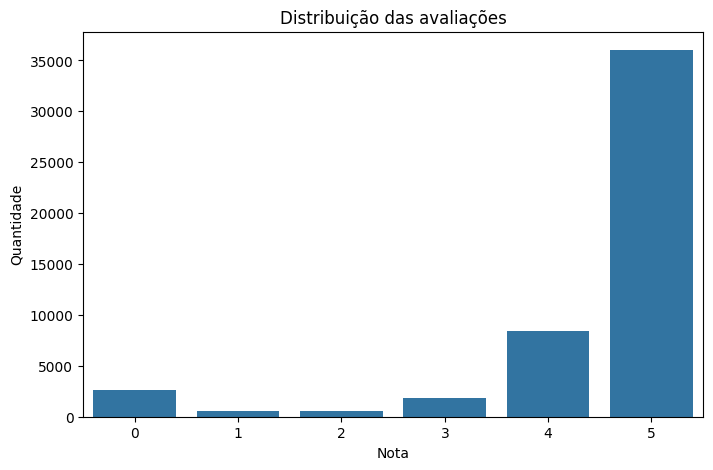

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=interacoes, x="rating")
plt.title("Distribuição das avaliações")
plt.xlabel("Nota")
plt.ylabel("Quantidade")
plt.show()

## 12. Análise do tempo de preparo

In [15]:
receitas["minutes"].describe()

count     10000.000000
mean        155.683100
std        2636.218867
min           0.000000
25%          20.000000
50%          38.000000
75%          65.000000
max      201610.000000
Name: minutes, dtype: float64

## 13. Gráfico do tempo de preparo

Aqui usamos um limite visual para evitar que valores extremos atrapalhem o gráfico.

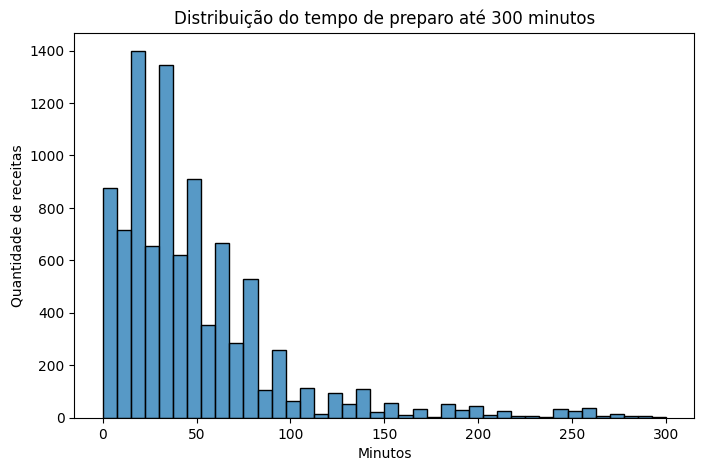

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(receitas[receitas["minutes"] <= 300]["minutes"], bins=40)
plt.title("Distribuição do tempo de preparo até 300 minutos")
plt.xlabel("Minutos")
plt.ylabel("Quantidade de receitas")
plt.show()

## 14. Calcular esparsidade da matriz usuário-item

In [17]:
qtd_usuarios = interacoes["user_id"].nunique()
qtd_receitas_avaliadas = interacoes["recipe_id"].nunique()
qtd_interacoes_realizadas = interacoes.shape[0]

total_possivel = qtd_usuarios * qtd_receitas_avaliadas
esparsidade = 1 - (qtd_interacoes_realizadas / total_possivel)

print("Esparsidade:", round(esparsidade * 100, 2), "%")

Esparsidade: 99.98 %


## 15. Função para transformar listas em texto

As colunas `ingredients` e `tags` vêm como texto parecido com lista.
Esta função transforma esses valores em texto simples.

In [18]:
def transformar_lista_texto(valor):
    try:
        lista = ast.literal_eval(valor)
        if isinstance(lista, list):
            return " ".join([str(item) for item in lista])
        return str(valor)
    except:
        return str(valor)

## 16. Preparar dados das receitas

In [19]:
receitas_modelo = receitas.copy()

# Remove linhas sem informações essenciais
receitas_modelo = receitas_modelo.dropna(subset=["id", "name", "ingredients", "tags"])

# Preenche tempo de preparo ausente com a mediana
receitas_modelo["minutes"] = receitas_modelo["minutes"].fillna(receitas_modelo["minutes"].median())

# Remove valores extremos de tempo de preparo usando o percentil 99
limite_tempo = receitas_modelo["minutes"].quantile(0.99)
receitas_modelo = receitas_modelo[receitas_modelo["minutes"] <= limite_tempo]

# Transforma ingredientes e tags em texto
receitas_modelo["ingredientes_texto"] = receitas_modelo["ingredients"].apply(transformar_lista_texto)
receitas_modelo["tags_texto"] = receitas_modelo["tags"].apply(transformar_lista_texto)

# Junta as informações usadas pelo modelo
receitas_modelo["texto_modelo"] = (
    receitas_modelo["ingredientes_texto"].fillna("") + " " +
    receitas_modelo["tags_texto"].fillna("") + " " +
    receitas_modelo["description"].fillna("")
)

receitas_modelo[["id", "name", "texto_modelo"]].head()

,id,name,texto_modelo
0,137739,arriba baked winter squash mexican style,winter squash mexican seasoning mixed spice ho...
1,31490,a bit different breakfast pizza,prepared pizza crust sausage patty eggs milk s...
2,112140,all in the kitchen chili,ground beef yellow onions diced tomatoes tomat...
3,59389,alouette potatoes,spreadable cheese with garlic and herbs new po...
4,44061,amish tomato ketchup for canning,tomato juice apple cider vinegar sugar salt pe...


## 17. Criar matriz TF-IDF

In [20]:
vetorizador = TfidfVectorizer(max_features=5000, stop_words="english")
matriz_receitas = vetorizador.fit_transform(receitas_modelo["texto_modelo"])

print("Formato da matriz TF-IDF:", matriz_receitas.shape)

Formato da matriz TF-IDF: (9905, 5000)


## 18. Treinar modelo de recomendação

Aqui usamos KNN com similaridade do cosseno.

In [21]:
modelo_vizinhos = NearestNeighbors(metric="cosine", algorithm="brute")
modelo_vizinhos.fit(matriz_receitas)

print("Modelo treinado.")

Modelo treinado.


## 19. Criar função de recomendação

In [22]:
def recomendar_receitas_parecidas(indice_receita, quantidade=5):
    distancias, indices = modelo_vizinhos.kneighbors(
        matriz_receitas[indice_receita],
        n_neighbors=quantidade + 1
    )

    recomendacoes = receitas_modelo.iloc[indices[0][1:]][["id", "name", "minutes", "n_ingredients"]]
    recomendacoes = recomendacoes.copy()
    recomendacoes["distancia"] = distancias[0][1:]

    return recomendacoes

## 20. Gerar recomendações de exemplo

In [23]:
indice_exemplo = 0

print("Receita base:")
print(receitas_modelo.iloc[indice_exemplo]["name"])

recomendacoes = recomendar_receitas_parecidas(indice_exemplo, quantidade=5)
recomendacoes

Receita base:
arriba   baked winter squash mexican style


,id,name,minutes,n_ingredients,distancia
2487,246568,acorn squash with boursin custard,30,4,0.677790
2488,195903,acorn squash with butter pecan sauce,75,5,0.683485
2452,65041,acorn or butternut squash risotto,40,7,0.699156
2494,76433,acorn squash with filberts or pecans,95,9,0.699647
2496,102749,acorn squash with raisin sauce,20,7,0.703646


## 21. Avaliar linha de base com RMSE e MAE

Como prova de conceito, usamos a média global das notas como previsão simples.

In [24]:
media_global = treino["rating"].mean()
previsoes = np.repeat(media_global, len(teste))

rmse = np.sqrt(mean_squared_error(teste["rating"], previsoes))
mae = mean_absolute_error(teste["rating"], previsoes)

print("Média global:", round(media_global, 2))
print("RMSE:", round(rmse, 4))
print("MAE:", round(mae, 4))

Média global: 4.58
RMSE: 1.3874
MAE: 0.8789


## 22. Precision@K e Recall@K simplificados

Nesta versão inicial, consideramos relevante uma receita com nota maior ou igual a 4.

In [25]:
def calcular_precision_recall_k(tabela_teste, k=10, nota_relevante=4):
    usuarios = tabela_teste["user_id"].drop_duplicates().head(100)

    lista_precision = []
    lista_recall = []

    receitas_populares = (
        treino.groupby("recipe_id")["rating"]
        .mean()
        .sort_values(ascending=False)
        .head(k)
        .index
        .tolist()
    )

    for usuario in usuarios:
        itens_relevantes = tabela_teste[
            (tabela_teste["user_id"] == usuario) &
            (tabela_teste["rating"] >= nota_relevante)
        ]["recipe_id"].tolist()

        if len(itens_relevantes) == 0:
            continue

        acertos = len(set(receitas_populares).intersection(set(itens_relevantes)))

        precision = acertos / k
        recall = acertos / len(itens_relevantes)

        lista_precision.append(precision)
        lista_recall.append(recall)

    return np.mean(lista_precision), np.mean(lista_recall)

precision_10, recall_10 = calcular_precision_recall_k(teste, k=10)

print("Precision@10:", round(precision_10, 4))
print("Recall@10:", round(recall_10, 4))

Precision@10: 0.0
Recall@10: 0.0


## 23. Salvar resultado das recomendações

In [26]:
recomendacoes.to_csv(pasta_saida / "recomendacoes_exemplo.csv", index=False)
print("Arquivo salvo em:", pasta_saida / "recomendacoes_exemplo.csv")

Arquivo salvo em: C:\Mackenzie Ciencia Dados\4 Semestre\Projeto aplicado 3\Projeto_3\outputs\recomendacoes_exemplo.csv
